In [2]:
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

uploaded = files.upload()
filename = next(iter(uploaded))
print("File chosen:", filename)


Saving burung.jpg to burung (1).jpg
File chosen: burung (1).jpg


In [4]:
# Baca sebagai grayscale
img = cv2.imdecode(np.frombuffer(uploaded[filename], np.uint8), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise SystemExit("Gagal membaca gambar. Pastikan file valid.")

# Definisikan kernel
kern_lpf = (1/9.0) * np.ones((3,3), dtype=np.float32)
kern_hpf = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], dtype=np.float32)
kern_bpf = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=np.float32)

# Terapkan filter
lpf = cv2.filter2D(img.astype(np.float32), -1, kern_lpf, borderType=cv2.BORDER_REPLICATE)
hpf = cv2.filter2D(img.astype(np.float32), -1, kern_hpf, borderType=cv2.BORDER_REPLICATE)
bpf = cv2.filter2D(img.astype(np.float32), -1, kern_bpf, borderType=cv2.BORDER_REPLICATE)


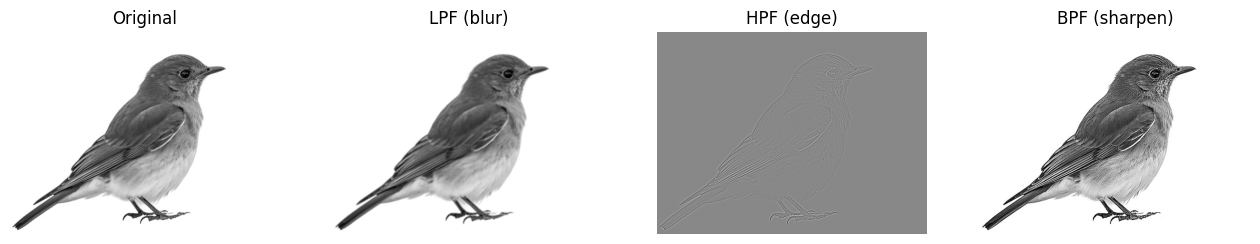

In [5]:
plt.figure(figsize=(16,6))
plt.subplot(1,4,1); plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(np.clip(lpf,0,255).astype(np.uint8), cmap='gray'); plt.title('LPF (blur)'); plt.axis('off')
plt.subplot(1,4,3);
# hpf bisa punya nilai negatif; normalisasi untuk tampilan
hpf_disp = hpf.copy()
hpf_min, hpf_max = hpf_disp.min(), hpf_disp.max()
if hpf_max - hpf_min > 0:
    hpf_disp = (hpf_disp - hpf_min) / (hpf_max - hpf_min) * 255
plt.imshow(hpf_disp.astype(np.uint8), cmap='gray'); plt.title('HPF (edge)'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(np.clip(bpf,0,255).astype(np.uint8), cmap='gray'); plt.title('BPF (sharpen)'); plt.axis('off')
plt.show()


In [6]:
means = {
    "original": float(img.astype(np.float32).mean()),
    "LPF": float(lpf.mean()),
    "HPF": float(hpf.mean()),
    "BPF": float(bpf.mean())
}
print("Mean pixel values (before clipping/normalization):")
for k,v in means.items():
    print(f" - {k}: {v:.4f}")

# Simpan gambar hasil ke folder results
os.makedirs("results", exist_ok=True)
cv2.imwrite("results/original.png", img)
cv2.imwrite("results/lpf.png", np.clip(lpf,0,255).astype(np.uint8))
# save normalized HPF for visualization
cv2.imwrite("results/hpf_norm.png", hpf_disp.astype(np.uint8))
cv2.imwrite("results/bpf.png", np.clip(bpf,0,255).astype(np.uint8))

# Zip dan download (opsional)
import shutil
shutil.make_archive("results_soal2", 'zip', "results")
files.download("results_soal2.zip")


Mean pixel values (before clipping/normalization):
 - original: 220.8026
 - LPF: 220.8026
 - HPF: 0.0000
 - BPF: 220.8026


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>